## Linear Regression using Multiple Features

So far, we've used on the "age" feature to estimate "charges". Adding another feature like "bmi" is fairly straightforward. We simply assume the following relationship:

$charges = w_1 \times age + w_2 \times bmi + b$

We need to change just one line of code to include the BMI.

In [58]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [59]:
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

In [60]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [61]:
medical_df = pd.read_csv('medical.csv')
non_somker_df = medical_df[medical_df.smoker == 'no']

In [62]:
from sklearn.linear_model import LinearRegression

# Create inputs and targets
inputs, targets = non_somker_df[['age', 'bmi']], non_somker_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute the loss to evaluate the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 4662.3128354612945


As you can see, adding the BMI doesn't seem to reduce the loss by much, as the BMI has a very weak correlation with charges, especially for non smokers.

In [63]:
non_somker_df.charges.corr(non_somker_df.bmi)

np.float64(0.0840365431283327)

In [64]:
fig = px.scatter(non_somker_df, x='bmi', y='charges', title='BMI vs Charges')
fig.update_traces(marker_size=5)
fig.show()

We can also visualize the relationship between all 3 variables "age", "bmi" and "charges" using a 3D scatter plot.

In [65]:
fig = px.scatter_3d(non_somker_df, x='age', y='bmi', z='charges')
fig.update_traces(marker_size=3, marker_opacity=0.5)
fig.show()

You can see that it's harder to interpret a 3D scatter plot compared to a 2D scatter plot. As we add more features, it becomes impossible to visualize all feature at once, which is why we use measures like correlation and loss. 

Let's also check the parameters of the model.

In [66]:
model.coef_, model.intercept_

(array([266.87657817,   7.07547666]), np.float64(-2293.6320906488727))

Clearly, BMI has a much lower weightage, and you can see why. It has a tiny contribution, and even that is probably accidental. This is an important thing to keep in mind: you can't find a relationship that doesn't exist, no matter what machine learning technique or optimization algorithm you apply. 

> **EXERCISE**: Train a linear regression model to estimate charges using BMI alone. Do you expect it to be better or worse than the previously trained models?

In [67]:
X = non_somker_df[['bmi']]
y = non_somker_df.charges

model = LinearRegression().fit(X, y)

predictions = model.predict(X)

rmse(y, predictions)

np.float64(5969.772531913293)

Let's go one step further, and add the final numeric column: "children", which seems to have some correlation with "charges".

$charges = w_1 \times age + w_2 \times bmi + w_3 \times children + b$

In [68]:
non_somker_df.charges.corr(non_somker_df.children)

np.float64(0.13892870453542183)

In [69]:
fig = px.strip(non_somker_df, x='children', y='charges', title='Children vs Charges')
fig.update_traces(marker_size=4, marker_opacity=0.7)
fig.show()

In [70]:
# Create inputs and targets
inputs, targets = non_somker_df[['age', 'bmi', 'children']], non_somker_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# COmpute loss to evaluate the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 4608.470405038247


Once again, we don't see a big reduction in the loss, even though it's greater than in the case of BMI.

> **EXERCISE**: Repeat the steps is this section to train a linear regression model to estimate medical charges for smokers. Visualize the targets and predictions, and compute the loss.

In [71]:
smokers_df = medical_df[medical_df.smoker == 'yes']

In [72]:
X = smokers_df[['age', 'bmi', 'children']]
y = smokers_df.charges

model = LinearRegression().fit(X, y)

predictions = model.predict(X)

loss = rmse(y, predictions)
print('Loss:', loss)

Loss: 5718.202480524154


Text(0.5, 1.0, 'Predicted vs Actual (smokers)')

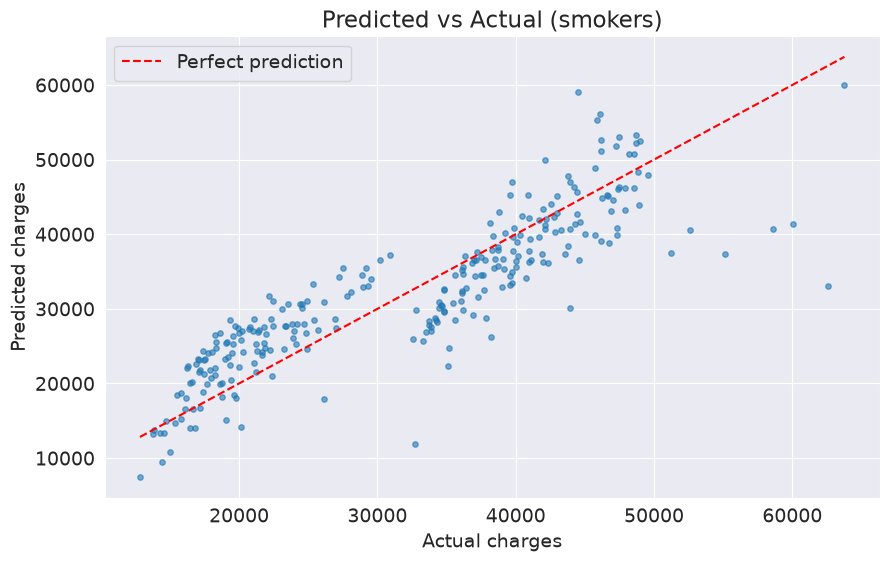

In [73]:
plt.scatter(y, predictions, alpha=0.6, s=15) # real and predicted
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect prediction') # line of all possible charges
plt.xlabel('Actual charges')
plt.ylabel('Predicted charges')
plt.legend()
plt.title('Predicted vs Actual (smokers)')

## Predicted vs Actual Plots

**Why this plot instead of a line on a feature axis:**
With one feature, the model is a line `charges = w*age + b`, so we could plot it on a 2D axis. With multiple features (`age`, `bmi`, `children`), there's no single line to draw anymore — the prediction depends on several inputs at once. So instead we compare `actual` vs `predicted` directly, which works no matter how many features the model has.

**How to read it:**
- x-axis = real value, y-axis = predicted value, each point = one person.
- If a point falls on the diagonal, `predicted == actual` (perfect prediction).
- Farther from the line = bigger error. Above the line = overestimate, below = underestimate.

**The reference line:**
```python
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect prediction')
```
`plt.plot()` just connects the given points with straight segments — 2 points fully define a line. Both points here have equal x and y (`(y.min(), y.min())` and `(y.max(), y.max())`), so they satisfy `x == y`. The line connecting them is exactly the diagonal `Y = X`, and since it spans the full range of `y`, it covers the whole scatter without needing extra points.

**The rest:**
```python
plt.scatter(y, predictions, alpha=0.6, s=15)  # actual vs predicted, one point per person
```
`alpha` = transparency (helps when points overlap), `s` = point size.

> **EXERCISE**: Repeat the steps is this section to train a linear regression model to estimate medical charges for all customers. Visualize the targets and predictions, and compute the loss. Is the loss lower or higher?

In [74]:
# Create inputs and targets
inputs, targets = medical_df[['age', 'bmi', 'children']], medical_df.charges

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evaluate the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 11355.317901125973


Let's explore how smoker affects charges

In [75]:
px.scatter(medical_df, x='age', y='charges', color='smoker')

Text(0.5, 1.0, 'Real vs Predicted')

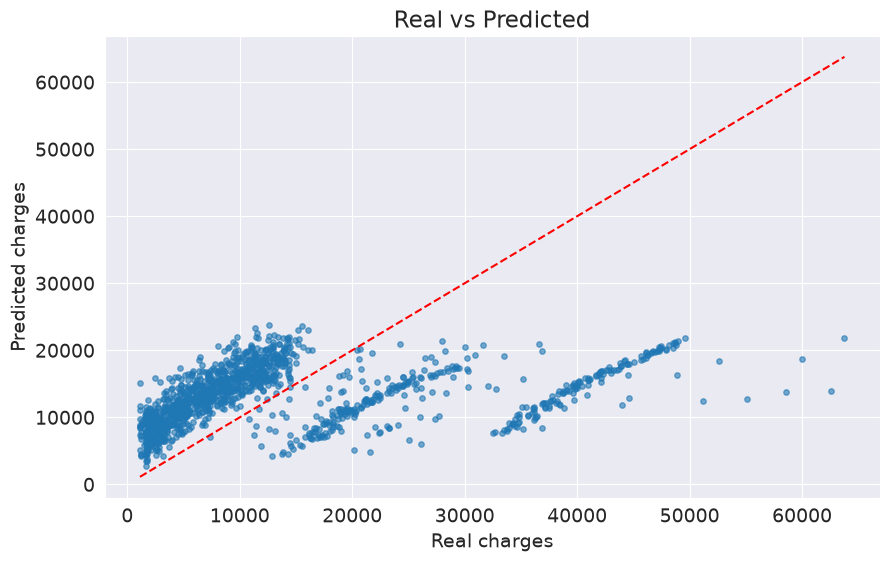

In [76]:
plt.scatter(targets, predictions, s=15, alpha=0.6)
plt.plot([targets.min(), targets.max()], [targets.min(), targets.max()], 'r--', label='Perfect prediction')
plt.xlabel('Real charges')
plt.ylabel('Predicted charges')
plt.title('Real vs Predicted')

## Using Categorical Features for Machine Learning

So far we've been using only numeric columns, since we can only perform computations with numbers. If we could use categorical columns like "smoker", we can train a single model for the entire dataset.

To use the categorical columns, we simply need to convert them to numbers. There are three common techniques for doing this:

1. If a categorical column has just two categories (it's called a binary category), then we can replace their values with 0 and 1.
2. If a categorical column has more than 2 categories, we can perform one-hot encoding i.e. create a new column for each category with 1s and 0s.
3. If the categories have a natural order (e.g. cold, neutral, warm, hot), then they can be converted to numbers (e.g. 1, 2, 3, 4) preserving the order. These are called ordinals



## Binary Categories

The "smoker" category has just two values "yes" and "no". Let's create a new column "smoker_code" containing 0 for "no" and 1 for "yes".

<Axes: xlabel='smoker', ylabel='charges'>

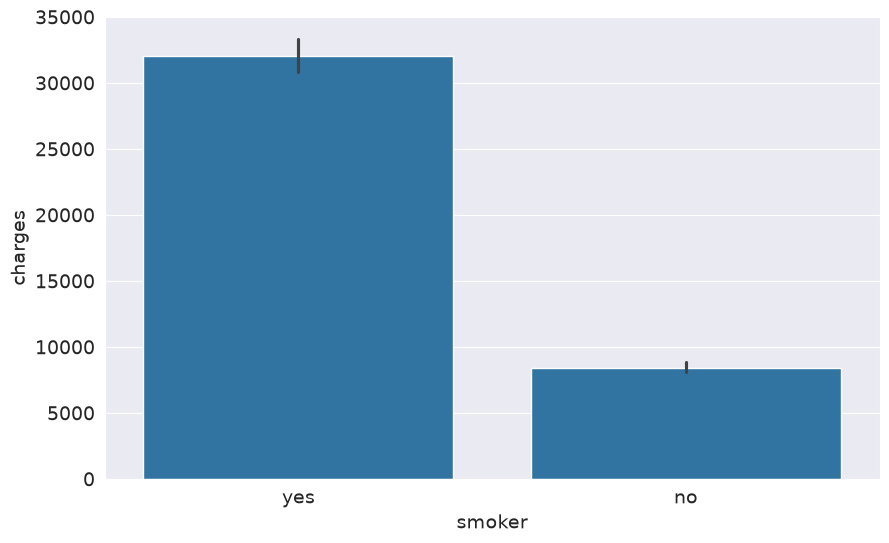

In [77]:
sns.barplot(data=medical_df, x='smoker', y='charges')

In [78]:
smoker_codes = {'no': 0, 'yes': 1}
medical_df['smoker_code'] = medical_df.smoker.map(smoker_codes)

In [79]:
medical_df.charges.corr(medical_df.smoker_code)

np.float64(0.7872514304984782)

In [80]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


We can now use the `smoker_df` column for linear regression.

$charges = w_1 \times age + w_2 \times bmi + w_3 \times children + w_4 \times smoker + b$

In [81]:
# Create inputs and targets
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_code']], medical_df['charges']

# Create and train the model 
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evaluate the model
loss = rmse(targets, predictions)
print('Loss', loss)

Loss 6056.439217188081


The loss reduces from `11355` to `6056`, almost by 50%! This is an important lesson: never ignore categorical data.


Let's try adding the "sex" column as well.

$charges = w_1 \times age + w_2 \times bmi + w_3 \times children + w_4 \times smoker + w_5 \times sex + b$

<Axes: xlabel='sex', ylabel='charges'>

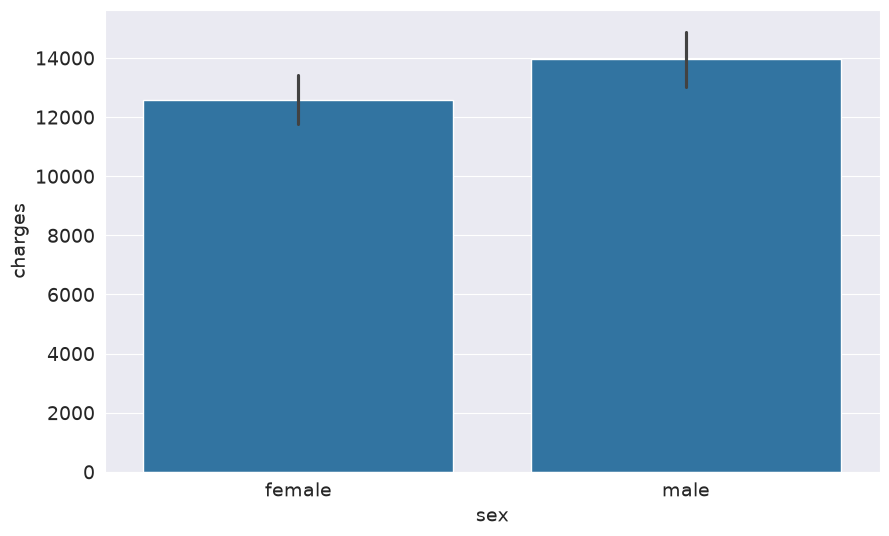

In [82]:
sns.barplot(data=medical_df, x='sex', y='charges')

In [83]:
sex_codes = {'female': 0, 'male': 1}

In [84]:
medical_df['sex_code'] = medical_df.sex.map(sex_codes)

In [85]:
medical_df.charges.corr(medical_df.sex_code)

np.float64(0.05729206220202531)

In [86]:
# Create inputs and targets
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_code', 'sex_code']], medical_df.charges

# Create and train the  model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# compute loss to evaluate the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6056.100708754546


As you might expect, this does have a significant impact on the loss.

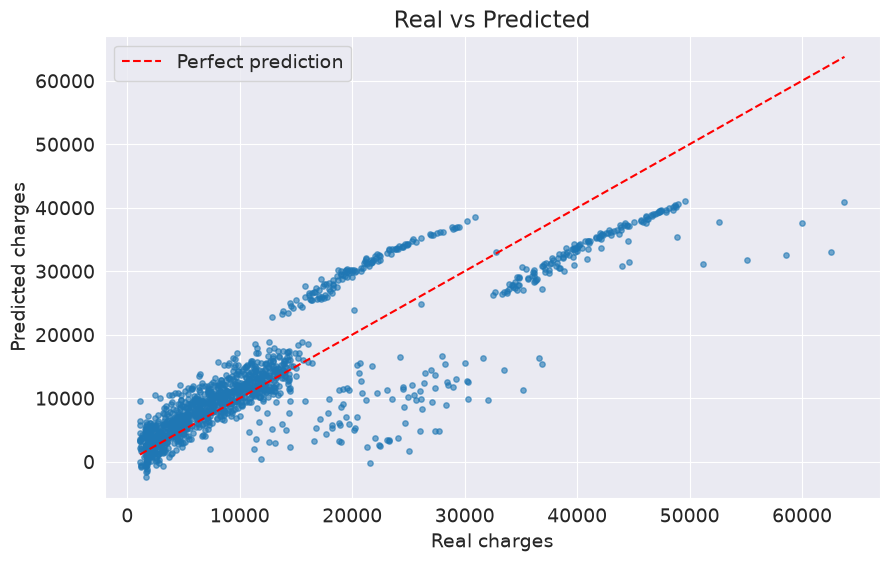

In [87]:
plt.scatter(targets, predictions, s=15, alpha=0.6)
plt.plot([targets.min(), targets.max()], [targets.min(), targets.max()], 'r--', label='Perfect prediction')
plt.xlabel('Real charges')
plt.ylabel('Predicted charges')
plt.title('Real vs Predicted')
plt.legend()


### One-hot Encoding

The "region" column contains 4 values, so we'll need to use hot encoding and create a new column for each region.

![](https://i.imgur.com/n8GuiOO.png)

## 🔍 Deep Dive: One-Hot Encoding with Scikit-Learn

### ❓ Why not just use numbers (1, 2, 3, 4)?
If we assign numbers to regions (e.g., `northeast=1`, `southwest=4`), the model might incorrectly assume a **mathematical order**. It could think that "southwest" is *four times greater* than "northeast", or that the difference between `1` and `2` is the same as `3` and `4`.
*   **Reality:** Regions are **nominal** (categories without order).
*   **Solution:** **One-Hot Encoding** creates a separate binary column (0 or 1) for each category, ensuring no false mathematical relationship exists.

---

### 💻 Code Breakdown: Line by Line

Let's analyze the Scikit-Learn approach:

#### 1. Initialization
```python
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()   

#### 2. Learning the Categories (`.fit()`)
```python
enc.fit(medical_df[['region']])   

Crucial Step: The encoder scans the data and memorizes the unique categories: ['northeast', 'northwest', 'southeast', 'southwest'].
It establishes the "vocabulary" and the specific order of columns it will expect forever.

---

### 🏆 Why use `OneHotEncoder` instead of Pandas `get_dummies`?

You might wonder: *"Why not just use `pd.get_dummies()`?"*

While `get_dummies` is great for quick exploration, **`OneHotEncoder` is the industry standard for Machine Learning** because it solves three important problems:

1. **Consistency between Train & Test** ⚠️
   `get_dummies()` only creates columns for categories present in the current dataset. If the Train and Test sets contain different categories, their columns won't match and **the model can fail**. `OneHotEncoder` learns the expected categories during `.fit()` and always produces the **same feature columns**.

2. **Unknown Categories** 🛡️
   With `handle_unknown='ignore'`, unseen categories (e.g., `"central"`) are safely encoded instead of causing errors.

3. **Pipeline Integration** 🤖
   `OneHotEncoder` is a Scikit-Learn transformer, making it fully compatible with `Pipeline` objects and production workflows. `pd.get_dummies()` is simply a Pandas function.

> **💡 Key Takeaway:** Use `pd.get_dummies()` for quick data exploration, but prefer **`OneHotEncoder`** when training, testing, or deploying Machine Learning models.


<Axes: xlabel='region', ylabel='charges'>

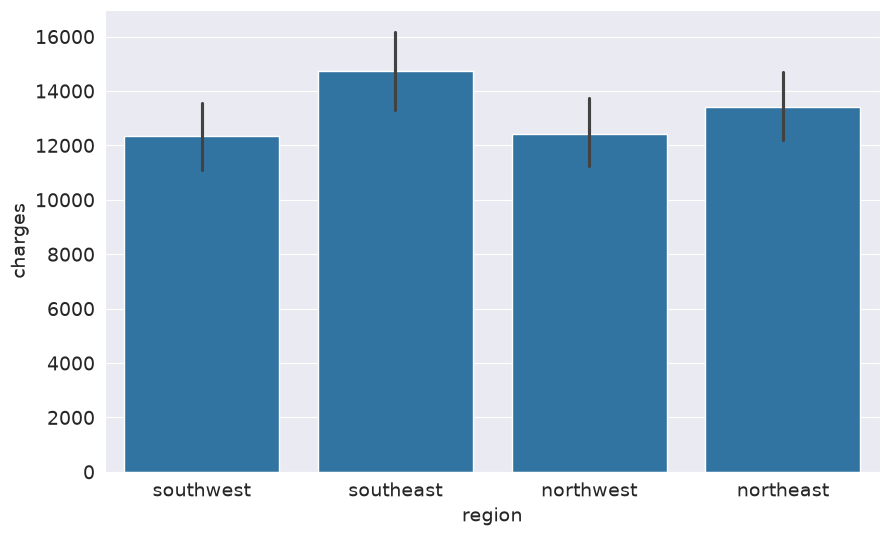

In [88]:
sns.barplot(data=medical_df, x='region', y='charges')

In [89]:
# Imports the preprocessing module from Scikit-Learn, which contains various tools for data transformation.
from sklearn import preprocessing

# Creates an instance of the OneHotEncoder class.
# At this point, enc is an empty object; it doesn't know what categories exist yet.
enc = preprocessing.OneHotEncoder()

# Fit the Encoder (Learn Categories)
# Crucial Step: The encoder scans the region column to find all unique values.
# It internally stores the "vocabulary": ['northeast', 'northwest', 'southeast', 'southwest'].
# This order is fixed. The encoder will always expect columns in this specific order for any future data.
enc.fit(medical_df[['region']])

# Verify Learned Categories
enc.categories_
# Returns the list of unique categories found during .fit().
#This confirms the mapping: Index 0 = 'northeast', Index 1 = 'northwest', etc.

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [90]:
# Transform Data to One-Hot Vectors
one_hot = enc.transform(medical_df[['region']]).toarray()
# .transform(...): Converts each row's category into a binary vector based on the learned order.
    # Example: If row 0 is 'southwest' (index 3), it becomes [0., 0., 0., 1.].
# .toarray(): By default, Scikit-Learn returns a Sparse Matrix (efficient for storage with many zeros). 
# This method converts it to a standard Dense NumPy Array so we can view and manipulate it easily.

one_hot
# Displays the resulting matrix. Each row corresponds to a patient, and each column corresponds to
# a region (in the order learned). Only one column per row is 1. (active), the rest are 0..

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]], shape=(1338, 4))

In [91]:
medical_df[['northeast', 'northwest', 'southeast', 'southwest']] = one_hot
# Creates four new columns in the original medical_df with the specified names.
# Assigns the binary data from the one_hot array to these columns.
# The DataFrame now has numeric features ready for the Linear Regression model.

In [92]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


Let's include the region columns into our linear regression model.

$charges = w_1 \times age + w_2 \times bmi + w_3 \times children + w_4 \times smoker + w_5 \times sex + w_6 \times region + b$

In [93]:
# Create inputs and targets
input_cols = ['age', 'bmi', 'children', 'smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
inputs, targets = medical_df[input_cols], medical_df['charges']

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6041.6796511744515


Once again, this leads to a fairly small reduction in the loss. 

> **EXERCISE**: Are two separate linear regression models, one for smokers and one of non-smokers, better than a single linear regression model? Why or why not? Try it out and see if you can justify your answer with data.

In [94]:
# Smokers
smokers_df = medical_df[medical_df.smoker == 'yes']

feature_columns = ['age', 'bmi', 'children', 'smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
X = smokers_df[feature_columns]
y = smokers_df.charges

model_smokers = LinearRegression().fit(X, y)

predictions = model_smokers.predict(X)

rmse(y, predictions)

np.float64(5668.4678821121515)

In [95]:
# Non smokers
non_somker_df = medical_df[medical_df.smoker == 'no']

X = non_somker_df[feature_columns]
y = non_somker_df.charges

model_non_somkers = LinearRegression().fit(X, y)

predictions = model_non_somkers.predict(X)

rmse(y, predictions)

np.float64(4573.074988795492)

## Model Improvements

Let's discuss and apply some more improvements to our model.

### Feature Scaling

Recall that due to regulatory requirements, we also need to explain the rationale behind the predictions our model. 

$charges = w_1 \times age + w_2 \times bmi + w_3 \times children + w_4 \times smoker + w_5 \times sex + w_6 \times region + b$

To compare the importance of each feature in the model, our first instinct might be to compare their weights. 

In [96]:
model.coef_

array([  256.85635254,   339.19345361,   475.50054515, 23848.53454191,
        -131.3143594 ,   587.00923503,   234.0453356 ,  -448.01281436,
        -373.04175627])

In [97]:
model.intercept_

np.float64(-12525.547811195458)

In [98]:
weights_df = pd.DataFrame({
    'feature': np.append(input_cols, 1),
    'weight': np.append(model.coef_, model.intercept_)
})

weights_df

,feature,weight
0,age,256.856353
1,bmi,339.193454
2,children,475.500545
3,smoker_code,23848.534542
4,sex_code,-131.314359
5,northeast,587.009235
6,northwest,234.045336
7,southeast,-448.012814
8,southwest,-373.041756
9,1,-12525.547811


### 1. The Problem: Why Raw Weights are Misleading

While it seems like **BMI** and the **"northeast"** region have a higher weight than **age** in our initial model, keep in mind that the range of values for each feature is vastly different:
*   **BMI**: Limited range (15 to 40).
*   **Northeast**: Binary values (only 0 and 1).
*   **Age**: Wider range (18 to 64+).

Because different columns have different ranges, we run into two critical issues:

1.  **Incomparable Importance**: We cannot compare the weights of different columns to identify which features are truly important. A higher weight might just mean the input numbers are smaller, not that the feature matters more.
2.  **Optimization Dominance**: A column with a larger range of inputs may disproportionately affect the loss function and dominate the optimization process. As illustrated below, the optimizer struggles to find a balanced solution when features are on different scales.

![](https://i.imgur.com/dT5fLFI.png)

In [112]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


## 2. The Solution: StandardScaler

We use `StandardScaler` to transform numeric features so they have a **Mean of 0** and a **Standard Deviation of 1**.

The transformation formula (**Z-score**) applied is:

$$ z = \frac{x - \mu}{\sigma} $$

Where:
*   $x$ is the original value.
*   $\mu$ is the mean (calculated via `.fit()`).
*   $\sigma$ is the standard deviation.

**Result:** All numeric columns now represent *"how many standard deviations away from the average"* a value is. This puts all features on a **comparable footing**, allowing the model weights to reflect true feature importance rather than just the scale of the input data.   

In [100]:
from sklearn.preprocessing import StandardScaler

In [ ]:
numeric_cols = ['age', 'bmi', 'children'] 

# 1. Initialize the scaler
scaler = StandardScaler()

# 2. Calculate Mean (μ) and Standard Deviation (σ)
# This step computes scaler.mean_ (μ) and scaler.scale_ (σ) internally
scaler.fit(medical_df[numeric_cols]) # Fit the Scaler on numeric data only

StandardScaler()

In [102]:
scaler.mean_

array([39.20702541, 30.66339686,  1.09491779])

In [103]:
scaler.var_

array([197.25385199,  37.16008997,   1.45212664])

We can now scale data as follows:

In [ ]:
# 3. APPLY THE FORMULA: z = (x - μ) / σ
# This line executes the full operation:
# - x: medical_df[numeric_cols] (original values)
# - μ: scaler.mean_ (subtracts the mean)
# - σ: scaler.scale_ (divides by standard deviation)
# Result: scaled_inputs contains the 'z' values (standardized data)
scaled_inputs = scaler.transform(medical_df[numeric_cols])
scaled_inputs

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]], shape=(1338, 3))

These can now we combined with the categorical data

In [ ]:
cat_cols = ['smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
categorical_data = medical_df[cat_cols].values # Extract categorical data (no scaling needed)

In [ ]:
# Concatenate scaled numeric columns (z) with original categorical columns
inputs = np.concatenate((scaled_inputs, categorical_data), axis=1) # axis=1 means "append columns side-by-side"
targets = medical_df.charges

# Create and train the model using the transformed data (z)
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6041.6796511744515


### Why didn't the RMSE change?

You might notice the loss is effectively the same as before scaling. This is expected.

**Linear Regression (OLS)** finds the mathematically optimal line regardless of the scale of the inputs. Scaling changes the values of the coefficients, but not the predictive power of the model.

### Why do it then?

*   **Interpretability**: We can now compare weights directly.
*   **Optimization Stability**: Crucial for algorithms using Gradient Descent (like Neural Networks or SGD Regressors), though less critical for the closed-form ODE solution used by standard Linear Regression.   

We can now compare the weights in the formula:

$charges = w_1 \times age + w_2 \times bmi + w_3 \times children + w_4 \times smoker + w_5 \times sex + w_6 \times region + b$

In [107]:
weights_df = pd.DataFrame({
    'feature': np.append(numeric_cols + cat_cols, 1),
    'weight': np.append(model.coef_, model.intercept_)
})
weights_df.sort_values('weight', ascending=False)

,feature,weight
3,smoker_code,23848.534542
9,1,8466.483215
0,age,3607.472736
1,bmi,2067.691966
5,northeast,587.009235
2,children,572.998210
6,northwest,234.045336
4,sex_code,-131.314359
8,southwest,-373.041756
7,southeast,-448.012814


### Conclusion: True Feature Importance

Now that the scales are equal, the magnitude of the coefficients (`model.coef_`) directly indicates feature importance.

### Key Findings

*   **smoker_code**: Has the highest weight by far (~23,848). Being a smoker is the single most dominant factor in insurance charges.
*   **age**: The second most important feature.
*   **bmi**: Third in importance.

This confirms our earlier visual analysis: the `smoker` variable was the key to unlocking the model's accuracy, and scaling has now mathematically proven its dominance over other features.   